<a href="https://colab.research.google.com/github/sanya-sriv/Customer-Churn-Analysis-and-Prediction/blob/main/Customer_Churn_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1:Data Preparation**


**Description:**


In this task you'll be responsible for loading the database and conducting the intial exploration.Handle missing values,and if necessary,convert categorical variables into numerical representations.Furthermore,split the dataset into training and testing sets for subsequent model evaluation.

**Skills:**


*   Data loading,data exploration.
*   Handling missing values.

*   Data preprocessing

*   Categorical variable encoding.
*   Dataset splitting.







In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv("/content/Telco_Customer_Churn_Dataset  (3).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].median())

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


#**2.Handling Missing Values**

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# **3.Data Preprocessing and Categorical Variables Encoding**

In [ ]:
categorical_cols=df.select_dtypes(include=['object']).columns.to_list()
categorical_cols.remove('customerID')

In [ ]:
df=df.drop('customerID',axis=1)

In [ ]:
binary_cols=['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
  df[col]=df[col].map({'Yes':1,'No':0,'Male':1,'Female':0})

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['SeniorCitizen']=le.fit_transform(df['SeniorCitizen'])

In [ ]:
cols_to_encode_now = df.select_dtypes(include='object').columns.to_list()
df = pd.get_dummies(df, columns=cols_to_encode_now, drop_first=True)

#**4.Dataset Splitting**

In [ ]:
x=df.drop('Churn',axis=1)
y=df['Churn']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("x_train.shape:",x_train.shape)
print("x_test.shape:",x_test.shape)
print("y_train.shape:",y_train.shape)
print("y_test.shape:",y_test.shape)

x_train.shape: (5634, 30)
x_test.shape: (1409, 30)
y_train.shape: (5634,)
y_test.shape: (1409,)


# **Task 2: Exploratory Data Analysis (EDA)**

## **Description:**


Calculate and visually represent the overall
churn rate. Explore customer distribution by
gender, partner status, and dependent status.
Analyze tenure distribution and its relation
with churn. Investigate how churn varies
across different contract types and payment
methods.

## **Skills:**


* Data visualization, statistical analysis  
* Exploratory data analysis

*   Understanding of customer demographic
variables
*   Churn rate calculation.





# **Overall Churn Rate Calculation and Visualisation**

*  **What is churn rate?** This calculates the percentage of customer who left(churned).
*  **Visualize:** It then creates a bar chart to show this churn rate visually.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:

df = pd.read_csv('/content/Telco_Customer_Churn_Dataset  (3).csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Churn Rate:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


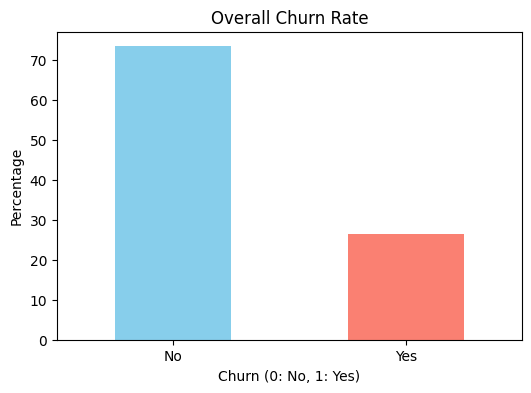

In [5]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate:\n{churn_rate}")

# Visualization
plt.figure(figsize=(6, 4))
churn_rate.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Overall Churn Rate')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_10129/1459092159.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(
/tmp/ipykernel_10129/1459092159.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(
/tmp/ipykernel_10129/1459092159.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(


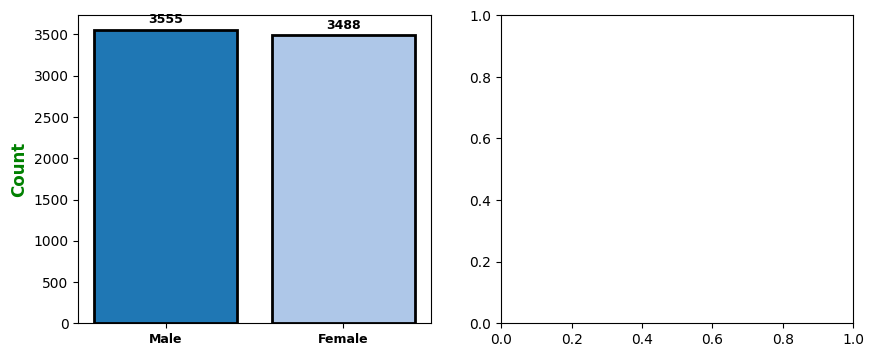

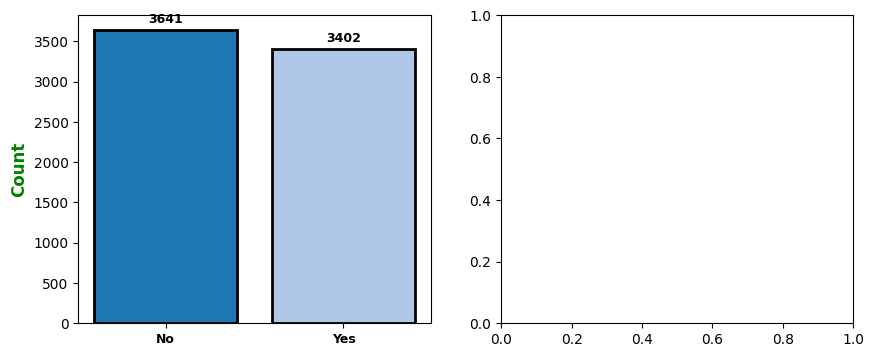

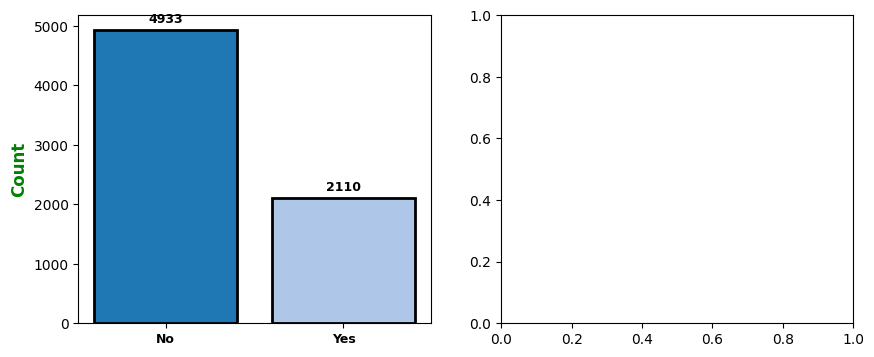

In [6]:
categorical_cols = ['gender', 'Partner', 'Dependents']  # changed variables here

for cat_cols in categorical_cols:

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # 1. We create our dataframe that contains our data to be displayed.
    df_plot_moment = df[cat_cols].value_counts().to_frame()

    # 2. We generate the values of our graphs.
    values = df_plot_moment.iloc[:, 0]

    # 3. We generate the labels for our charts.
    labels = df_plot_moment.index.to_list()

    # 4. We generate the color map.
    cmap = plt.get_cmap('tab20')
    colors = cmap(np.arange(len(labels)))

    # Bar chart
    rects = ax[0].bar(
        labels,
        values,
        color=colors,
        edgecolor='black',
        linewidth=2.0
    )

    ax[0].set_ylabel(
        'Count',
        fontsize=12,
        fontweight='bold',
        color='green'
    )

    ax[0].set_xticklabels(
        labels,
        fontsize=9,
        fontweight='bold'
    )

    # function to label our bars.
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()

            ax[0].annotate(
                text='{}'.format(height),
                xy=(rect.get_x() + rect.get_width()/2., height - 0.005),
                xytext=(0, 3),
                textcoords='offset points',
                va='bottom',
                ha='center',
                weight='bold',
                size=9,
                color='black'
            )

    autolabel(rects)  # we label our bars

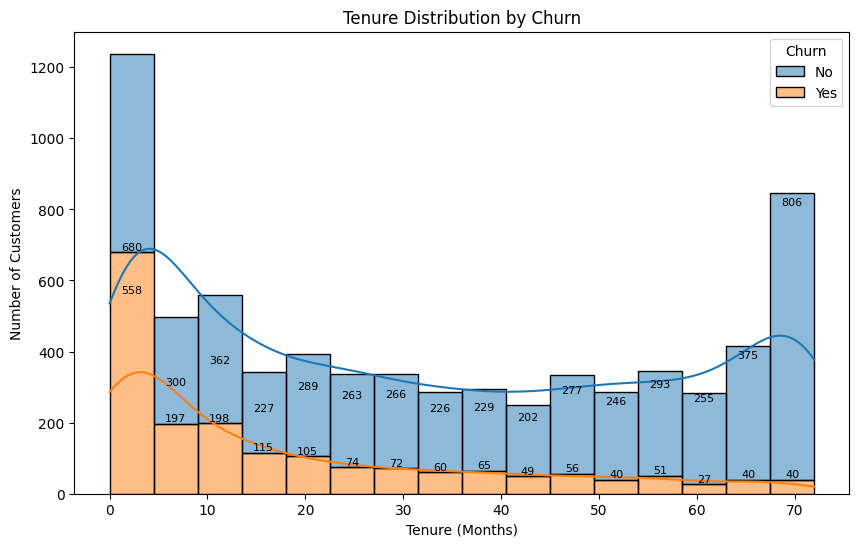

In [7]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True,
    multiple='stack'
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):  # Check for NaN values
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.show()

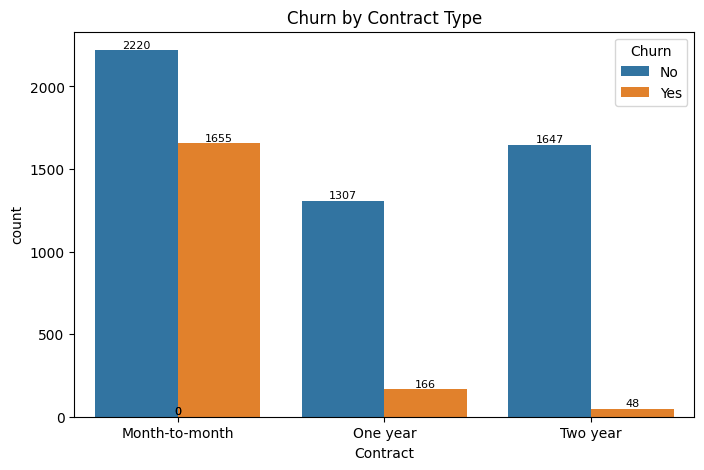

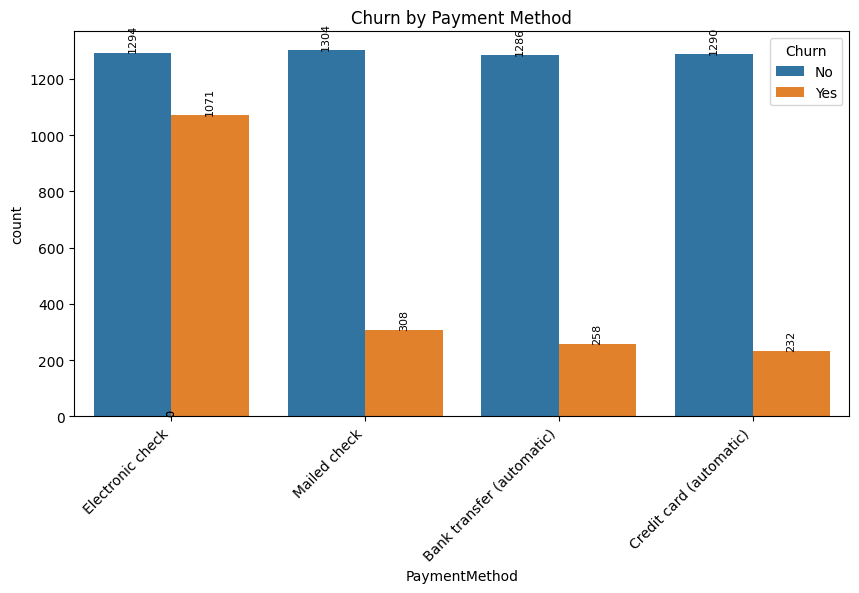

In [8]:
# Contract Type vs Churn
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8)

plt.show()


# Payment Method vs Churn
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn by Payment Method')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, rotation=90)

plt.show()

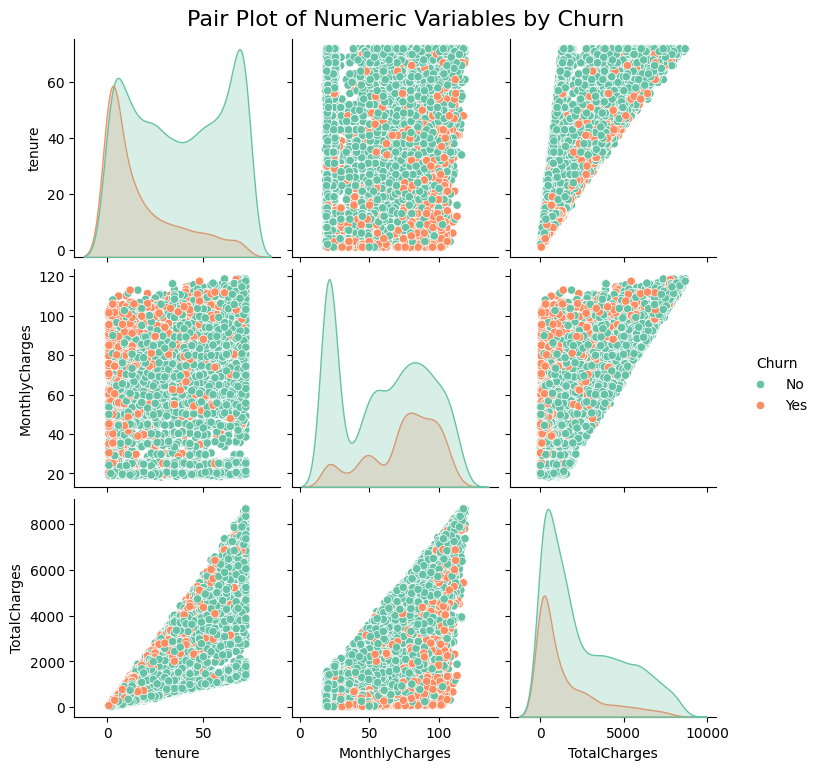

In [9]:
# Pair Plot for Numerical Features

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

numeric_variables = ['tenure', 'MonthlyCharges', 'TotalCharges']

sns.pairplot(
    df,
    vars=numeric_variables,
    hue='Churn',
    palette='Set2',
    diag_kind='kde',
    height=2.5
)

plt.suptitle('Pair Plot of Numeric Variables by Churn', y=1.02, fontsize=16)
plt.show()

In [10]:
# Feature Engineering

# Tenure in Years
df['TenureYears'] = df['tenure'] / 12

# Average Monthly Charge (if TotalCharges is meaningful)
df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure']
df['AvgMonthlyCharge'] = df['AvgMonthlyCharge'].replace([np.inf, -np.inf], 0)  # Handle division by zero

# Has Multiple Services: Combine multiple "Yes/No/No internet service" columns
internet_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in internet_cols:
    df[col] = df[col].map({
        'Yes': 1,
        'No': 0,
        'No internet service': 0
    })

df['MultipleServices'] = df[internet_cols].sum(axis=1)

# Automatic Payment Flag
df['IsAutomaticPayment'] = df['PaymentMethod'].apply(
    lambda x: 1 if 'automatic' in x.lower() else 0
)

# Check new features
df[['TenureYears', 'AvgMonthlyCharge', 'MultipleServices', 'IsAutomaticPayment']].head()

,TenureYears,AvgMonthlyCharge,MultipleServices,IsAutomaticPayment
0,0.083333,29.850000,1,0
1,2.833333,55.573529,2,0
2,0.166667,54.075000,2,0
3,3.750000,40.905556,3,1
4,0.166667,75.825000,0,0


In [11]:
# Statistical Analysis
from scipy.stats import chi2_contingency

# Chi-squared Tests (Categorical Features)

categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'IsAutomaticPayment']
print("\nChi-Squared Tests:")
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"\nFeature: {feature}")
    print(f"  Chi2 Statistic: {chi2:.4f}")
    print(f"  P-value: {p:.4f}")
    if p < 0.05:
        print("  ==> Statistically significant association with Churn")
    else:
        print("  ==> No statistically significant association with Churn")


Chi-Squared Tests:

Feature: gender
  Chi2 Statistic: 0.4755
  P-value: 0.4905
  ==> No statistically significant association with Churn

Feature: SeniorCitizen
  Chi2 Statistic: 158.4408
  P-value: 0.0000
  ==> Statistically significant association with Churn

Feature: Partner
  Chi2 Statistic: 157.5032
  P-value: 0.0000
  ==> Statistically significant association with Churn

Feature: Dependents
  Chi2 Statistic: 186.3216
  P-value: 0.0000
  ==> Statistically significant association with Churn

Feature: PhoneService
  Chi2 Statistic: 0.8737
  P-value: 0.3499
  ==> No statistically significant association with Churn

Feature: Contract
  Chi2 Statistic: 1179.5458
  P-value: 0.0000
  ==> Statistically significant association with Churn

Feature: PaperlessBilling
  Chi2 Statistic: 256.8749
  P-value: 0.0000
  ==> Statistically significant association with Churn

Feature: PaymentMethod
  Chi2 Statistic: 645.4299
  P-value: 0.0000
  ==> Statistically significant association with Churn

Fea

In [12]:
# T-tests or ANOVA (Numeric Features)
from scipy.stats import ttest_ind, f_oneway

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TenureYears', 'AvgMonthlyCharge', 'MultipleServices']
print("\nT-tests/ANOVA:")
for feature in numeric_features:
    churn_group = df[df['Churn'] == 1][feature]
    no_churn_group = df[df['Churn'] == 0][feature]

    if len(df[feature].unique()) > 5: # T-test if data looks roughly continuous
        t_stat, p_val = ttest_ind(churn_group, no_churn_group, equal_var=False) # Welch's t-test (unequal variances)
        print(f"\nFeature: {feature} (T-test)")
        print(f"  T-statistic: {t_stat:.4f}")
        print(f"  P-value: {p_val:.4f}")
        if p_val < 0.05:
            print("  ==> Statistically significant difference between churned and non-churned customers")
        else:
            print("  ==> No statistically significant difference")
    else: # ANOVA if more like discrete categories (though it's generally better to treat them as categorical)
        f_stat, p_val = f_oneway(churn_group, no_churn_group)
        print(f"\nFeature: {feature} (ANOVA)")
        print(f"  F-statistic: {f_stat:.4f}")
        print(f"  P-value: {p_val:.4f}")
        if p_val < 0.05:
            print("  ==> Statistically significant difference between churned and non-churned customers")
        else:
            print("  ==> No statistically significant difference")


T-tests/ANOVA:

Feature: tenure (T-test)
  T-statistic: nan
  P-value: nan
  ==> No statistically significant difference

Feature: MonthlyCharges (T-test)
  T-statistic: nan
  P-value: nan
  ==> No statistically significant difference

Feature: TotalCharges (T-test)
  T-statistic: nan
  P-value: nan
  ==> No statistically significant difference

Feature: TenureYears (T-test)
  T-statistic: nan
  P-value: nan
  ==> No statistically significant difference

Feature: AvgMonthlyCharge (T-test)
  T-statistic: nan
  P-value: nan
  ==> No statistically significant difference

Feature: MultipleServices (T-test)
  T-statistic: nan
  P-value: nan
  ==> No statistically significant difference


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [13]:
# Gender and Churn:
gender_churn = df.groupby('gender')['Churn'].value_counts(normalize=True) * 100
print("\nChurn Rate by Gender:\n", gender_churn)


Churn Rate by Gender:
 gender  Churn
Female  No       73.040482
        Yes      26.959518
Male    No       73.795435
        Yes      26.204565
Name: proportion, dtype: float64


In [14]:

# Senior Citizen and Churn:
senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True) * 100
print("\nChurn Rate by Senior Citizen Status:\n", senior_churn)


Churn Rate by Senior Citizen Status:
 SeniorCitizen  Churn
0              No       76.349745
               Yes      23.650255
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64


In [15]:

# Partner/Dependents and Churn:
partner_churn = df.groupby('Partner')['Churn'].value_counts(normalize=True) * 100
dependents_churn = df.groupby('Dependents')['Churn'].value_counts(normalize=True) * 100

print("\nChurn Rate by Partner Status:\n", partner_churn)
print("\nChurn Rate by Dependents Status:\n", dependents_churn)


Churn Rate by Partner Status:
 Partner  Churn
No       No       67.023908
         Yes      32.976092
Yes      No       80.282935
         Yes      19.717065
Name: proportion, dtype: float64

Churn Rate by Dependents Status:
 Dependents  Churn
No          No       68.720860
            Yes      31.279140
Yes         No       84.468795
            Yes      15.531205
Name: proportion, dtype: float64


## **Task 3: Customer Segmentation**

In [16]:
import pandas as pd

In [17]:
df = pd.read_csv('/content/Telco_Customer_Churn_Dataset  (3).csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [18]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Make a copy of the DataFrame to avoid modifying the original 'df' if it's used elsewhere
df_processed = df.copy()

# Drop 'customerID' as it is an identifier and not a feature for scaling or segmentation
if 'customerID' in df_processed.columns:
    df_processed = df_processed.drop('customerID', axis=1)

# Convert 'TotalCharges' to numeric, coercing errors to NaN, then fill NaNs
# This handles cases where 'TotalCharges' might contain empty strings or other non-numeric values
if 'TotalCharges' in df_processed.columns:
    df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')
    # Fill NaN values (e.g., from empty strings) with the mean of the column
    df_processed['TotalCharges'] = df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].mean())

# Identify categorical columns (object dtype) for one-hot encoding
categorical_cols = df_processed.select_dtypes(include='object').columns

# Apply one-hot encoding to convert categorical columns into numerical representation
# drop_first=True is often used to avoid multicollinearity
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)

For n_clusters = 2, the average silhouette_score is : 0.32584477275158685
For n_clusters = 3, the average silhouette_score is : 0.28041842666610917
For n_clusters = 4, the average silhouette_score is : 0.23577340491498958
For n_clusters = 5, the average silhouette_score is : 0.19945849960454923
For n_clusters = 6, the average silhouette_score is : 0.19412702880845692


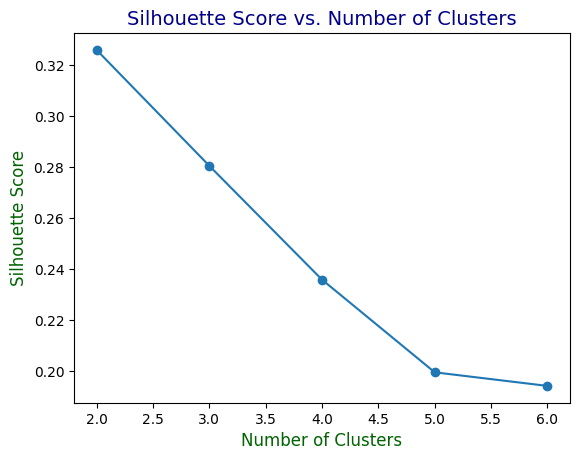

In [19]:
# K-Means Clustering with Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for n_clusters in range(2, 7):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(
        f"For n_clusters = {n_clusters}, "
        f"the average silhouette_score is : {silhouette_avg}"
    )

plt.plot(range(2, 7), silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters',
          fontsize=14, color='darkblue')
plt.xlabel('Number of Clusters',
           fontsize=12, color='darkgreen')
plt.ylabel('Silhouette Score',
           fontsize=12, color='darkgreen')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

In [20]:
optimal_clusters = 3

Churn Rate by Cluster:
 Churn          No       Yes
cluster                    
0        0.750733  0.249267
1        0.925950  0.074050
2        0.671975  0.328025


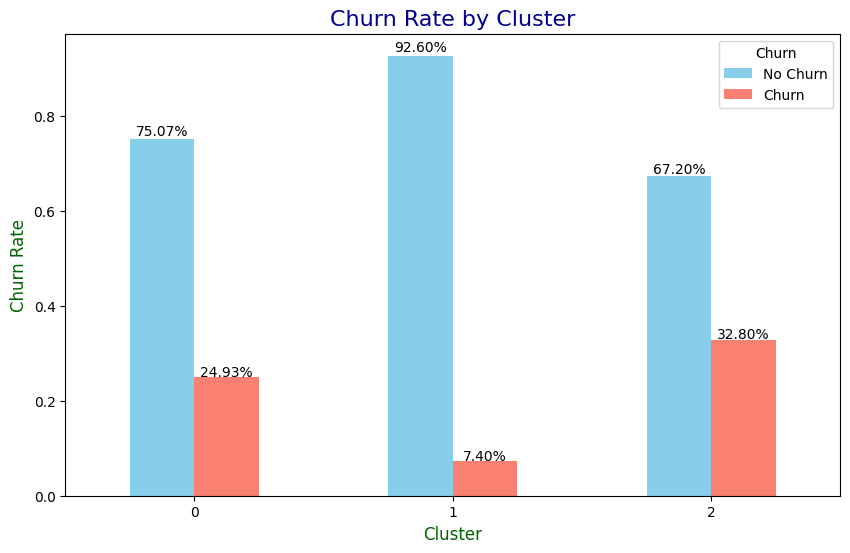

In [21]:
# Churn Analysis within Segments
from sklearn.cluster import KMeans

# Initialize KMeans with the optimal number of clusters found earlier
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init='auto')

# Fit KMeans and get cluster labels for the scaled data
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original DataFrame 'df'
df['cluster'] = cluster_labels

cluster_churn_rate = df.groupby('cluster')['Churn'].value_counts(normalize=True).unstack().fillna(0)
print("Churn Rate by Cluster:\n", cluster_churn_rate)

# Visualize churn rate by cluster with enhancements
ax = cluster_churn_rate.plot(
    kind='bar',
    stacked=False,
    figsize=(10, 6),
    color=['skyblue', 'salmon']
)

plt.title('Churn Rate by Cluster', fontsize=16, color='darkblue')
plt.xlabel('Cluster', fontsize=12, color='darkgreen')
plt.ylabel('Churn Rate', fontsize=12, color='darkgreen')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Add value annotations on top of the bars
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()

    ax.annotate(
        f'{height:.2%}',
        (x + width / 2, y + height * 1.01),
        ha='center',
        fontsize=10,
        color='black'
    )

plt.legend(title='Churn', labels=['No Churn', 'Churn'], fontsize=10)
plt.show()


High-Value Customer Churn Risk by Cluster:
 Churn          No       Yes
cluster                    
2        0.809739  0.190261


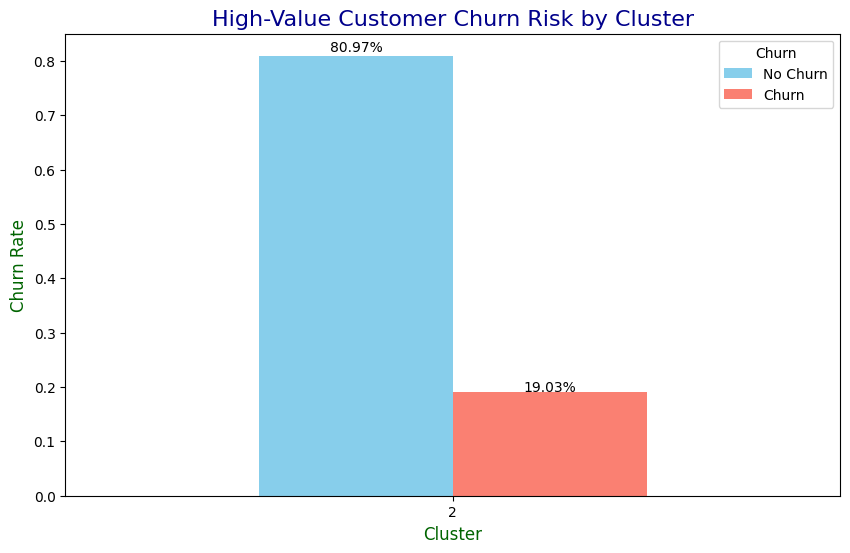


Example High-Value Customers at Risk (Cluster 2):

      customerID  MonthlyCharges  TotalCharges  tenure
13    0280-XJGEX          103.70       5036.30      49
26    6467-CHFZW           99.35       4749.15      47
104   3192-NQECA          110.00       7611.85      68
110   0486-HECZI           96.75       5238.90      55
173   0691-JVSYA           94.85       5000.20      53
...          ...             ...           ...     ...
6945  6797-LNAQX           98.30       6859.50      70
6952  6394-MFYNG          107.40       5121.30      48
6972  6664-FPDAC          111.95       6418.90      56
7006  0093-XWZFY          104.50       4036.85      40
7034  0639-TSIQW          102.95       6886.25      67

[211 rows x 4 columns]


In [22]:
# Identifying High-Value Customers at Risk of Churn

# Ensure 'TotalCharges' is numeric in df, handling potential non-numeric entries
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

high_value_threshold_monthly = df['MonthlyCharges'].quantile(0.75)
high_value_threshold_total = df['TotalCharges'].quantile(0.75)

high_value_customers = df[
    (df['MonthlyCharges'] >= high_value_threshold_monthly) &
    (df['TotalCharges'] >= high_value_threshold_total)
]

high_value_churn_risk = high_value_customers.groupby('cluster')['Churn'] \
    .value_counts(normalize=True).unstack().fillna(0)

print("\nHigh-Value Customer Churn Risk by Cluster:\n", high_value_churn_risk)

# Visualize high value churn risk with enhancements
import matplotlib.pyplot as plt
ax = high_value_churn_risk.plot(
    kind='bar',
    stacked=False,
    figsize=(10, 6),
    color=['skyblue', 'salmon']
)

plt.title('High-Value Customer Churn Risk by Cluster',
          fontsize=16, color='darkblue')
plt.xlabel('Cluster', fontsize=12, color='darkgreen')
plt.ylabel('Churn Rate', fontsize=12, color='darkgreen')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Add value annotations on top of the bars
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()

    ax.annotate(
        f'{height:.2%}',
        (x + width / 2, y + height * 1.01),
        ha='center',
        fontsize=10,
        color='black'
    )

plt.legend(title='Churn', labels=['No Churn', 'Churn'], fontsize=10)
plt.show()

highest_churn_cluster = high_value_churn_risk.index[
    high_value_churn_risk['Yes'].argmax()
]

at_risk_customers = high_value_customers[
    (high_value_customers['cluster'] == highest_churn_cluster) &
    (high_value_customers['Churn'] == 'Yes') # Assuming 'Churn' column stores 'Yes'/'No' strings
]

print(
    "\nExample High-Value Customers at Risk (Cluster {}):\n"
    .format(highest_churn_cluster)
)

if not at_risk_customers.empty:
    print(
        at_risk_customers[
            ['customerID', 'MonthlyCharges', 'TotalCharges', 'tenure']
        ]
    )
else:
    print("No high-value customers at risk found.")

In [23]:
# Cluster Profiles: Detailed Analysis of Each Cluster

print("\n--- Cluster Profiles ---")

# Add the cluster labels to the processed DataFrame
df_processed['cluster'] = cluster_labels

cluster_profiles = df_processed.groupby('cluster').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'gender_Male': 'mean',                # Proportion of males
    'Partner_Yes': 'mean',                # Proportion with partner
    'Dependents_Yes': 'mean',             # Proportion with dependents
    'SeniorCitizen': 'mean',              # Proportion of senior citizens
    'Contract_One year': 'mean',          # Proportion with one-year contract
    'Contract_Two year': 'mean',          # Proportion with two-year contract
    'InternetService_Fiber optic': 'mean',# Proportion using fiber optic
    'InternetService_No': 'mean',         # Proportion without internet
    'Churn_Yes': 'mean'                   # Churn rate (assuming 'Yes' is 1 after one-hot encoding)
})

print(cluster_profiles)


--- Cluster Profiles ---
            tenure  MonthlyCharges  TotalCharges  gender_Male  Partner_Yes  \
cluster                                                                      
0        31.737537       42.028592   1502.729547     0.514663     0.456012   
1        30.547182       21.079194    671.582374     0.510485     0.483617   
2        33.036194       81.755171   2902.086608     0.501551     0.486660   

         Dependents_Yes  SeniorCitizen  Contract_One year  Contract_Two year  \
cluster                                                                        
0              0.302053       0.152493           0.212610           0.236070   
1              0.421363       0.034076           0.238532           0.418087   
2              0.260807       0.203930           0.199380           0.185315   

         InternetService_Fiber optic  InternetService_No  Churn_Yes  
cluster                                                              
0                           0.000000      

In [24]:
# Identifying Key Drivers of Churn within Each Segment
# (This would ideally involve building a classification model,
# but for this example, we'll look at correlations)

print("\n--- Churn Correlation Analysis within Segments ---")

for cluster_id in range(optimal_clusters):  # Iterate through each cluster
    print(f"\n--- Correlation Analysis for Cluster {cluster_id} ---")

    cluster_data = df[df['cluster'] == cluster_id]

    # Select only numeric columns for correlation calculation
    numeric_columns = cluster_data.select_dtypes(include=np.number).columns

    if 'Churn' in numeric_columns:
        correlation_matrix = (
            cluster_data[numeric_columns]
            .corr()['Churn']
            .sort_values(ascending=False)
        )

        print(correlation_matrix)

    else:
        print("Churn column not found in numeric columns for this cluster.")


--- Churn Correlation Analysis within Segments ---

--- Correlation Analysis for Cluster 0 ---
Churn column not found in numeric columns for this cluster.

--- Correlation Analysis for Cluster 1 ---
Churn column not found in numeric columns for this cluster.

--- Correlation Analysis for Cluster 2 ---
Churn column not found in numeric columns for this cluster.


# **Task 4: Churn Prediction Model**

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Placeholder for defining X and y - replace with actual data loading and preprocessing
# In a real scenario, you would load your data, e.g., df = pd.read_csv('your_data.csv')
# And then define X and y from it, e.g., X = df.drop('target_column', axis=1), y = df['target_column']

# Dummy data for demonstration to resolve the NameError
X = pd.DataFrame(np.random.rand(100, 5)) # Example: 100 samples, 5 features
y = pd.Series(np.random.randint(0, 2, 100)) # Example: 100 samples, binary target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 5)
X_test shape: (20, 5)
y_train shape: (80,)
y_test shape: (20,)


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # Added this import
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Assuming X_train contains both numerical and (potentially) categorical features
# Define placeholder for numerical and categorical features. Adjust these lists based on your actual data.
# For the dummy data X = pd.DataFrame(np.random.rand(100, 5)), all features are numerical.
# If you have categorical features, you'll need to identify them and include them here.

# Example for dummy data (all numerical):
numerical_features = X_train.columns.tolist() # Assuming all columns in X_train are numerical
categorical_features = [] # No categorical features in dummy data

# If you had actual data with different feature types, it might look like this:
# numerical_features = ['feature1', 'feature2', 'numeric_col_A']
# categorical_features = ['gender', 'city', 'marital_status_col_B']

# Create a preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # Uncomment and adjust if you have categorical features
    ],
    remainder='passthrough' # Keep other columns not specified (if any)
)

# --- Model 1: Logistic Regression ---
pipeline_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10]
}

grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring='f1'
)

grid_search_lr.fit(X_train, y_train)

best_model_lr = grid_search_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_test)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results:")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print("-" * 30)


# --- Model 2: Decision Tree ---
pipeline_dt = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

param_grid_dt = {
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 3, 5]
}

grid_search_dt = GridSearchCV(
    pipeline_dt,
    param_grid_dt,
    cv=5,
    scoring='f1'
)

grid_search_dt.fit(X_train, y_train)

best_model_dt = grid_search_dt.best_estimator_
y_pred_dt = best_model_dt.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("-" * 30)



# --- Model 3: Random Forest ---
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='f1'
)

grid_search_rf.fit(X_train, y_train)

best_model_rf = grid_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("-" * 30)

Logistic Regression Results:
Best Parameters: {'classifier__C': 0.001}
Accuracy: 0.5000
Precision: 0.5000
Recall: 0.6000
F1-score: 0.5455
------------------------------
Decision Tree Results:
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Accuracy: 0.5500
Precision: 0.5294
Recall: 0.9000
F1-score: 0.6667
------------------------------
Random Forest Results:
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Accuracy: 0.5000
Precision: 0.5000
Recall: 0.6000
F1-score: 0.5455
------------------------------


In [27]:
# --- Model 1: Logistic Regression ---

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='liblinear',
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10]
}

grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring='f1'
)

grid_search_lr.fit(X_train, y_train)

best_model_lr = grid_search_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_test)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results:")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print("-" * 30)



# ---- Model 2: Decision Tree ----
pipeline_dt = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ]
)

param_grid_dt = {
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 3, 5]
}

grid_search_dt = GridSearchCV(
    pipeline_dt,
    param_grid_dt,
    cv=5,
    scoring='f1'
)

grid_search_dt.fit(X_train, y_train)

best_model_dt = grid_search_dt.best_estimator_
y_pred_dt = best_model_dt.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print(f"Best Parameters: {grid_search_dt.best_params_}")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("-" * 30)


# --- Model 3: Random Forest ---

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='f1'
)

grid_search_rf.fit(X_train, y_train)

best_model_rf = grid_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("-" * 30)

Logistic Regression Results:
Best Parameters: {'classifier__C': 0.001}
Accuracy: 0.5000
Precision: 0.5000
Recall: 0.6000
F1-score: 0.5455
------------------------------
Decision Tree Results:
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Accuracy: 0.5500
Precision: 0.5294
Recall: 0.9000
F1-score: 0.6667
------------------------------
Random Forest Results:
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Accuracy: 0.5000
Precision: 0.5000
Recall: 0.6000
F1-score: 0.5455
------------------------------


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance (Example with Random Forest)
try:
    if hasattr(best_model_rf.named_steps['classifier'], 'feature_importances_'):
        feature_importances = best_model_rf.named_steps['classifier'].feature_importances_

        # Get numerical feature names *before* scaling:
        numerical_feature_names = numerical_features.tolist()

        # Get one-hot encoded categorical feature names:
        categorical_feature_names = best_model_rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out().tolist()

        # Combine numerical and categorical feature names
        feature_names = numerical_feature_names + categorical_feature_names

        # Create a dataframe to display feature importances
        feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
        feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
        print("\nFeature Importances (Random Forest):")
        print(feature_importance_df)

        # Plotting Feature Importances
        plt.figure(figsize=(12, 8))
        plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'])
        plt.xlabel('Feature', fontsize=12, fontweight='bold', color='deeppink')
        plt.ylabel('Importance', fontsize=12, fontweight='bold', color='deeppink')
        plt.title('Random Forest Feature Importances', fontsize=14, fontweight='bold', color='forestgreen')
        plt.xticks(rotation=90, ha='right', fontsize=10) # Rotate x-axis labels for readability
        plt.tight_layout()

        # Annotate the bars with their values
        for i, v in enumerate(feature_importance_df['Importance']):
            plt.text(i, v + 0.01, str(round(v, 3)), ha='center', fontsize=8)

        plt.show()

except Exception as e:
    print(f"Could not display feature importances: {e}")

Could not display feature importances: 'list' object has no attribute 'tolist'



Confusion Matrix:
[[4 6]
 [4 6]]


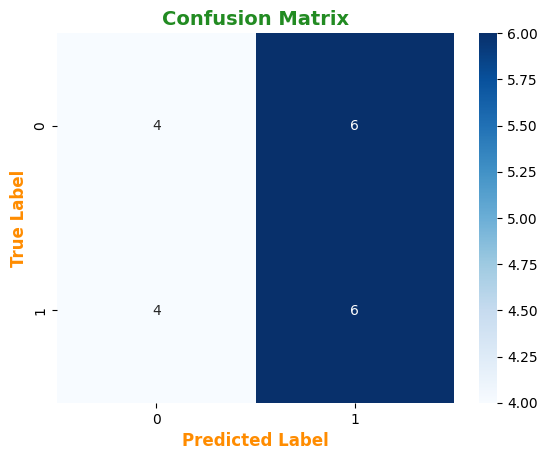

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix ---

# Assuming y_pred_rf is the prediction you want to visualize from the previous cell
cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm)

# --- Visualizing the Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")  # annot=True displays the values; fmt="d" formats as integers
plt.title("Confusion Matrix", fontsize=14, fontweight='bold', color='forestgreen')
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold', color='darkorange')
plt.ylabel("True Label", fontsize=12, fontweight='bold', color='darkorange')
plt.show()